In [2]:
from matplotlib import pyplot as plt
import networkx as nx
plt.style.use('seaborn-v0_8-whitegrid')

plot_kwargs = {"node_size" : 100, "edgecolors" : 'white', 
               "node_color" : "steelblue", "width" : 0.5, 
               "edge_color" : "darkgrey"}

small_fig_size = (3, 2)
big_fig_size = (6, 4)

This graph has 34 nodes and 78 edges.


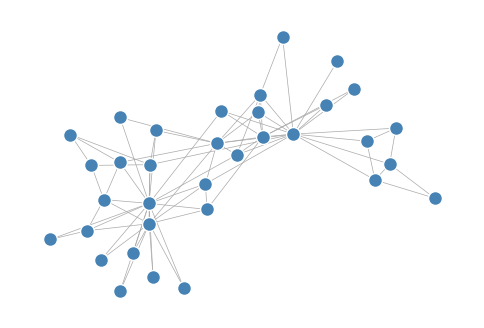

In [3]:
fig, ax = plt.subplots(1, 1, figsize = big_fig_size)

G = nx.karate_club_graph()
nx.draw(G, ax = ax, **plot_kwargs)

print('This graph has', G.number_of_nodes(), 'nodes and', G.number_of_edges(), 'edges.')

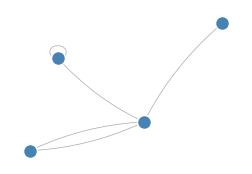

In [4]:
fig, ax = plt.subplots(1, 1, figsize = small_fig_size)

G = nx.MultiDiGraph()
G.add_edges_from([(1, 4), (2, 4), (3, 3), (3, 4), (4, 2)])

nx.draw(G, ax = ax, connectionstyle='arc3, rad = 0.1', arrows = True, arrowsize = 0.1, **plot_kwargs)

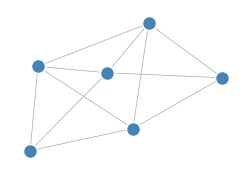

In [6]:
fig, ax = plt.subplots(1, 1, figsize = small_fig_size)

G = nx.Graph()
edgelist = [(1, 4), (2, 5), (3, 5), (4, 5), (5, 6),
            (6, 1), (1, 4), (3, 6), (2, 3), (2, 4),
            (1, 3), (4, 6)]
G.add_edges_from(edgelist)
nx.draw(G, ax = ax, **plot_kwargs)

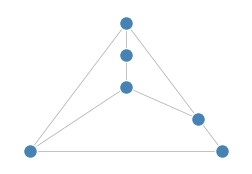

In [8]:
fig, ax = plt.subplots(1, 1, figsize = small_fig_size)
G = nx.Graph()
edgelist = [(1, 2), (2, 3), (3, 4), (4, 5),
            (5, 6), (6, 1), (1, 4), (3, 6)]
G.add_edges_from(edgelist)

nx.draw_planar(G, ax = ax, **plot_kwargs)

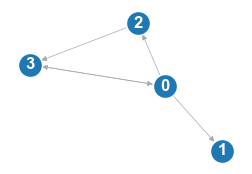

In [9]:
fig, ax = plt.subplots(1, 1, figsize = small_fig_size)

DG = nx.DiGraph()
DG.add_edges_from([(0, 1), (0, 2), (2, 3), (3, 0), (0, 3)])

nx.draw(DG, 
        with_labels = True, 
        arrowsize = 8, 
        font_color = 'white', 
        font_weight = 'bold',  
        ax = ax, 
        edgecolors = "white", 
        width = 0.5, 
        edge_color = "darkgrey")

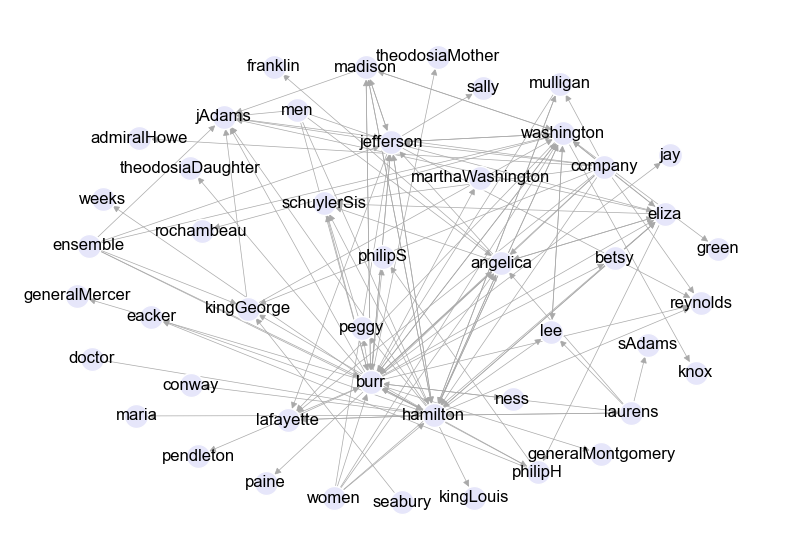

In [10]:
import pandas as pd

# import data for our directed network
df = pd.read_csv("https://philchodrow.github.io/PIC16A/homework/HW3-hamilton-data.csv", 
names = ["mentioner", "mentioned"])

df = df[df["mentioner"] != df["mentioned"]]

G_Hamilton = nx.from_pandas_edgelist(df, 
                            source = "mentioner", 
                            target = "mentioned", 
                            edge_attr=None, 
                            create_using=nx.DiGraph())

layout = nx.arf_layout(G_Hamilton)

fig, ax = plt.subplots(1, 1, figsize = (10, 7))
nx.draw(G_Hamilton, pos = layout,  with_labels = True, edge_color = "darkgrey", width = 0.5, node_color = "lavender", edgecolors = "white")

# This is a coding exercise in the live notes.

# Create and print a numpy array of node in-degrees and out-degrees directly from the adjacency matrix